In [4]:
import pandas as pd
import re
import nltk

# Télécharger les ressources NLTK nécessaires
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import pos_tag

STOP_WORDS = set(stopwords.words('english'))

df = pd.read_csv('data/data_raw.csv')
print(f'Dataset chargé : {df.shape}')
df.head(3)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_en

Dataset chargé : (5572, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...


In [5]:
def clean_text(text: str) -> str:
    # 1. Minuscules
    text = text.lower()
    # 2. Supprimer URLs
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    # 3. Supprimer adresses email
    text = re.sub(r'\S+@\S+', ' ', text)
    # 4. Supprimer balises HTML 
    text = re.sub(r'<[^>]+>', ' ', text)
    # 5. Supprimer chiffres
    text = re.sub(r'\d+', ' ', text)
    # 6. Supprimer ponctuation et caractères spéciaux
    text = re.sub(r'[^a-z\s]', ' ', text)
    # 7. Supprimer espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Test sur un exemple
example = df['text'][0]
print('AVANT :', example)
print('APRÈS :', clean_text(example))

AVANT : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
APRÈS : go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat


In [6]:
df['text_clean'] = df['text'].apply(clean_text)

# Comparaison avant/après sur quelques exemples spam
spam_examples = df[df['label'] == 'spam'][['text', 'text_clean']].head(5)
print('=== Exemples SPAM — avant / après cleaning ===')
for i, row in spam_examples.iterrows():
    print(f'\n[{i}] AVANT : {row["text"][:100]}')
    print(f'    APRÈS : {row["text_clean"][:100]}')

=== Exemples SPAM — avant / après cleaning ===

[2] AVANT : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entr
    APRÈS : free entry in a wkly comp to win fa cup final tkts st may text fa to to receive entry question std t

[5] AVANT : FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it s
    APRÈS : freemsg hey there darling it s been week s now and no word back i d like some fun you up for it stil

[8] AVANT : WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim
    APRÈS : winner as a valued network customer you have been selected to receivea prize reward to claim call cl

[9] AVANT : Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera f
    APRÈS : had your mobile months or more u r entitled to update to the latest colour mobiles with camera for f

[11] AVANT : SIX chances to win CASH! From 1

In [7]:
def tokenize(text: str) -> list:
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return tokens

df['tokens'] = df['text_clean'].apply(tokenize)

# Visualisation
example_idx = df[df['label'] == 'spam'].index[0]
print('Texte nettoyé :', df.loc[example_idx, 'text_clean'])
print('Tokens         :', df.loc[example_idx, 'tokens'])
print(f'Nb tokens      : {len(df.loc[example_idx, "tokens"])}')

Texte nettoyé : free entry in a wkly comp to win fa cup final tkts st may text fa to to receive entry question std txt rate t c s apply over s
Tokens         : ['free', 'entry', 'wkly', 'comp', 'win', 'fa', 'cup', 'final', 'tkts', 'st', 'may', 'text', 'fa', 'receive', 'entry', 'question', 'std', 'txt', 'rate', 'apply']
Nb tokens      : 20


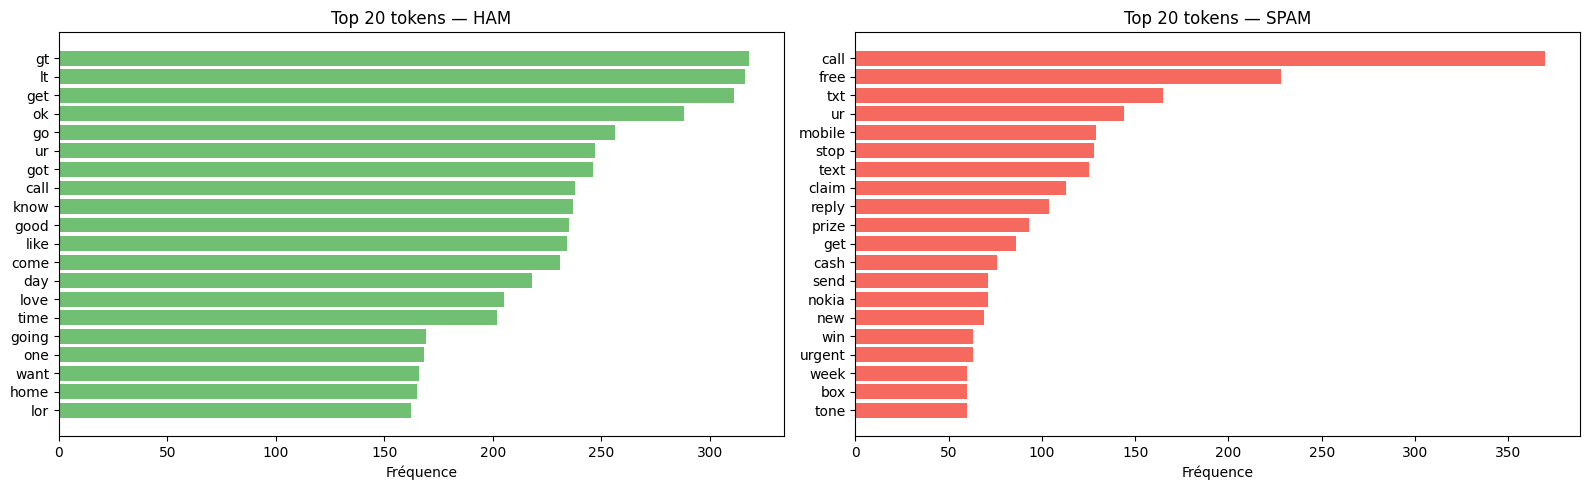

In [8]:
import matplotlib.pyplot as plt
from collections import Counter

# Top 20 tokens par label
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, label in zip(axes, ['ham', 'spam']):
    all_tokens = [t for tokens in df[df['label']==label]['tokens'] for t in tokens]
    most_common = Counter(all_tokens).most_common(20)
    words, counts = zip(*most_common)
    color = '#4CAF50' if label == 'ham' else '#F44336'
    ax.barh(words[::-1], counts[::-1], color=color, alpha=0.8)
    ax.set_title(f'Top 20 tokens — {label.upper()}')
    ax.set_xlabel('Fréquence')
plt.tight_layout()
plt.show()

In [9]:
# ── Stemming ────────────────────────────────────────────────────────────────
porter = PorterStemmer()
snowball = SnowballStemmer('english')

def apply_stemming(tokens: list, stemmer=porter) -> list:
    return [stemmer.stem(t) for t in tokens]

# Comparaison Porter vs Snowball
test_words = ['running', 'studies', 'flies', 'beautiful', 'connection', 'generously']
print(f'{"Mot":<15} {"Porter":<15} {"Snowball":<15}')
print('-' * 45)
for w in test_words:
    print(f'{w:<15} {porter.stem(w):<15} {snowball.stem(w):<15}')

Mot             Porter          Snowball       
---------------------------------------------
running         run             run            
studies         studi           studi          
flies           fli             fli            
beautiful       beauti          beauti         
connection      connect         connect        
generously      gener           generous       


In [10]:
# ── Lemmatisation avec POS Tagging ──────────────────────────────────────────
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag: str) -> str:
    """Convertit le tag POS de NLTK vers le format WordNet."""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN  # défaut

def apply_lemmatization(tokens: list) -> list:
    """Lemmatise en tenant compte du POS tag pour plus de précision."""
    tagged = pos_tag(tokens)
    return [lemmatizer.lemmatize(token, get_wordnet_pos(tag)) for token, tag in tagged]

# Comparaison sur les mots de test
print(f'{"Mot":<15} {"Lemme (sans POS)":<20} {"Lemme (avec POS)":<20}')
print('-' * 55)
for w in test_words:
    without_pos = lemmatizer.lemmatize(w)
    # Simuler le POS tag sur un seul mot
    with_pos = apply_lemmatization([w])[0]
    print(f'{w:<15} {without_pos:<20} {with_pos:<20}')

Mot             Lemme (sans POS)     Lemme (avec POS)    
-------------------------------------------------------
running         running              run                 
studies         study                study               
flies           fly                  fly                 
beautiful       beautiful            beautiful           
connection      connection           connection          
generously      generously           generously          


In [11]:
# ── Application au dataset ───────────────────────────────────────────────────
print('Application du stemming...')
df['tokens_stemmed'] = df['tokens'].apply(apply_stemming)

print('Application de la lemmatisation...')
df['tokens_lemmatized'] = df['tokens'].apply(apply_lemmatization)

# Comparaison sur un exemple spam
idx = df[df['label'] == 'spam'].index[1]
print('\n=== Comparaison sur un exemple SPAM ===')
print(f'Original    : {df.loc[idx, "tokens"][:10]}')
print(f'Stemmed     : {df.loc[idx, "tokens_stemmed"][:10]}')
print(f'Lemmatized  : {df.loc[idx, "tokens_lemmatized"][:10]}')

Application du stemming...
Application de la lemmatisation...

=== Comparaison sur un exemple SPAM ===
Original    : ['freemsg', 'hey', 'darling', 'week', 'word', 'back', 'like', 'fun', 'still', 'tb']
Stemmed     : ['freemsg', 'hey', 'darl', 'week', 'word', 'back', 'like', 'fun', 'still', 'tb']
Lemmatized  : ['freemsg', 'hey', 'darling', 'week', 'word', 'back', 'like', 'fun', 'still', 'tb']


In [12]:
# On joint les tokens en string pour pouvoir les vectoriser ensuite
df['text_tokens']      = df['tokens'].apply(' '.join)
df['text_stemmed']     = df['tokens_stemmed'].apply(' '.join)
df['text_lemmatized']  = df['tokens_lemmatized'].apply(' '.join)

df.to_csv('data_preprocessed.csv', index=False)
print(' data_preprocessed.csv sauvegardé')
df[['label', 'text', 'text_clean', 'text_tokens', 'text_stemmed', 'text_lemmatized']].head()

 data_preprocessed.csv sauvegardé


,label,text,text_clean,text_tokens,text_stemmed,text_lemmatized
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,go jurong point crazy available bugis great wo...,go jurong point crazi avail bugi great world l...,go jurong point crazy available bugis great wo...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni,ok lar joking wif oni,ok lar joke wif oni,ok lar joking wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...,free entry wkly comp win fa cup final tkts st ...,free entri wkli comp win fa cup final tkt st m...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,dun say early hor already say,dun say earli hor alreadi say,dun say early hor already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...,nah think goes usf lives around though,nah think goe usf live around though,nah think go usf life around though
